In [1]:
# --- Imports & style ---
import os, re, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "serif"
})

# --- Paths & experiment ---
EXPERIMENT = "lucas"  # non-linear LUCAS
ROOT_DIR   = f"data/{EXPERIMENT}/evaluation_results"  # evaluation outputs from run_nonlinear_evaluation.py

# --- Method label maps (flexible; will fallback to raw names if unknown) ---
label_map = {
    # DiRoCA typical runs (update if you used different eps/delta)
    r'DiRoCA (eps_0.107_delta_0.035)': 'DiRoCA_star',
    r'DiRoCA (eps_1.0_delta_1.0)'     : 'DIROCA_1',
    r'DiRoCA (eps_2.0_delta_2.0)'     : 'DIROCA_2',
    r'DiRoCA (eps_4.0_delta_4.0)'     : 'DIROCA_4',
    r'DiRoCA (eps_8.0_delta_8.0)'     : 'DIROCA_8',
    # Baselines
    r'GradCA'                         : 'GradCA',
    r'BaryCA'                         : 'BARYCA',
    r'Abs-LiNGAM (Perfect)'           : 'Abslin_p',
    r'Abs-LiNGAM (Noisy)'             : 'Abslin_n',
}

print_label_map  = {
    'DiRoCA_star':  r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$',
    'DIROCA_1':     r'DiRoCA$_{1,1}$',
    'DIROCA_2':     r'DiRoCA$_{2,2}$',
    'DIROCA_4':     r'DiRoCA$_{4,4}$',
    'DIROCA_8':     r'DiRoCA$_{8,8}$',
    'GradCA':       r'GRAD$_{(\tau, \omega)}$',
    'BARYCA':       r'BARY$_{(\tau, \omega)}$',
    'Abslin_p':     r'AbsLin$_{\text{p}}$',
    'Abslin_n':     r'AbsLin$_{\text{n}}$'
}

# palette
methods_to_plot = [
    'DiRoCA_star', 'DIROCA_1', 'DIROCA_2', 'DIROCA_4', 'DIROCA_8',
    'GradCA', 'BARYCA', 'Abslin_p', 'Abslin_n'
]
display_names = [print_label_map[m] for m in methods_to_plot]
color_map = {
    r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$': '#1f77b4',
    r'DiRoCA$_{1,1}$': 'gold',
    r'DiRoCA$_{2,2}$': 'darkorange',
    r'DiRoCA$_{4,4}$': 'lightskyblue',
    r'DiRoCA$_{8,8}$': 'violet',
    r'GRAD$_{(\tau, \omega)}$': '#2ca02c',
    r'BARY$_{(\tau, \omega)}$': '#d62728',
    r'AbsLin$_{\text{p}}$': '#9467bd',
    r'AbsLin$_{\text{n}}$': '#8c564b'
}



In [2]:
def list_nonlinear_results(root_dir=ROOT_DIR):
    """
    Find CSVs produced by run_nonlinear_evaluation.py.
    Filenames look like:
      nonlinear_empirical_eval_{distribution}_{shift_type}_a{...}_{range}_s{...}_{range}_tr{trials}_{timestamp}.csv
    """
    pattern = os.path.join(root_dir, "nonlinear_empirical_eval_*_*.csv")
    files = sorted(glob.glob(pattern))
    print(f"Found {len(files)} files in {root_dir}")
    return files

def parse_eval_filename(path):
    """
    Extract (distribution, shift_type, alpha_grid, noise_grid, trials, timestamp) from filename.
    """
    base = os.path.basename(path)
    m = re.match(
        r"nonlinear_empirical_eval_([a-z\-]+)_([a-z\-]+)"
        r"_a(\d+)_([0-9.]+)-([0-9.]+)"
        r"_s(\d+)_([0-9.]+)-([0-9.]+)"
        r"_tr(\d+)_([0-9]{8}_[0-9]{6})\.csv$",
        base
    )
    if not m:
        return None
    dist, shift = m.group(1), m.group(2)
    a_steps, a_min, a_max = int(m.group(3)), float(m.group(4)), float(m.group(5))
    s_steps, s_min, s_max = int(m.group(6)), float(m.group(7)), float(m.group(8))
    trials, ts = int(m.group(9)), m.group(10)
    return {
        'distribution': dist, 'shift_type': shift,
        'alpha_steps': a_steps, 'alpha_min': a_min, 'alpha_max': a_max,
        'noise_steps': s_steps, 'noise_min': s_min, 'noise_max': s_max,
        'trials': trials, 'timestamp': ts, 'path': path
    }

def pick_result(distribution='gaussian', shift_type='additive',
                alpha_steps=10, alpha_min=0.0, alpha_max=1.0,
                noise_steps=20, noise_min=0.0, noise_max=10.0,
                trials=20, root_dir=ROOT_DIR):
    """
    Pick the most recent file matching the requested grid.
    """
    candidates = []
    for p in list_nonlinear_results(root_dir):
        meta = parse_eval_filename(p)
        if meta is None:
            continue
        ok = (
            meta['distribution'] == distribution and
            meta['shift_type'] == shift_type and
            meta['alpha_steps'] == alpha_steps and
            abs(meta['alpha_min'] - alpha_min) < 1e-9 and
            abs(meta['alpha_max'] - alpha_max) < 1e-9 and
            meta['noise_steps'] == noise_steps and
            abs(meta['noise_min'] - noise_min) < 1e-9 and
            abs(meta['noise_max'] - noise_max) < 1e-9 and
            meta['trials'] == trials
        )
        if ok:
            candidates.append(meta)
    if not candidates:
        print("No matching result file found.")
        return None
    # pick latest by timestamp
    candidates.sort(key=lambda d: d['timestamp'])
    chosen = candidates[-1]
    print("Loading:", os.path.basename(chosen['path']))
    print(f"Parameters: {chosen['distribution']} {chosen['shift_type']}, "
          f"α: {chosen['alpha_steps']} steps ({chosen['alpha_min']}-{chosen['alpha_max']}), "
          f"noise: {chosen['noise_steps']} steps ({chosen['noise_min']}-{chosen['noise_max']}), "
          f"trials: {chosen['trials']}")
    df = pd.read_csv(chosen['path'])
    return df

def map_methods(df, label_map, print_label_map):
    """
    Map raw 'method' to compact code names and then to pretty display names.
    Unknown methods fall back to their original names.
    """
    df = df.copy()
    df['method'] = df['method'].map(lambda m: label_map.get(m, m))
    df['display_name'] = df['method'].map(lambda m: print_label_map.get(m, m))
    return df


In [3]:
# Choose the noise level you want on the α-scan
NOISE_TO_PLOT = 10.0   # e.g., if you ran noise_max=10.0 in evaluation

df = pick_result(
    distribution='gaussian', shift_type='additive',
    alpha_steps=10, alpha_min=0.0, alpha_max=1.0,
    noise_steps=20, noise_min=0.0, noise_max=NOISE_TO_PLOT,
    trials=20, root_dir=ROOT_DIR
)

if df is None:
    display(pd.DataFrame({'info': ['No data found']}))
else:
    dfm = map_methods(df, label_map, print_label_map)
    # filter: fixed noise_scale
    panel = dfm[(np.abs(dfm['noise_scale'] - NOISE_TO_PLOT) < 1e-9) &
                (dfm['display_name'].isin(display_names))].copy()
    if panel.empty:
        print("No rows at the requested noise level.")
    else:
        fig, ax = plt.subplots(1, 1, figsize=(9, 6))
        sns.lineplot(
            data=panel, x='alpha', y='error',
            hue='display_name', hue_order=display_names,
            palette=color_map, marker='o', linewidth=2.5, markersize=7,
            errorbar='sd', ax=ax, legend=False
        )
        ax.set_title("Non-linear LUCAS — Fix $\\tilde{\\sigma}$, vary $\\alpha$ (Gaussian)", fontsize=18)
        ax.set_xlabel(r'$\alpha$', fontsize=18)
        ax.set_ylabel('Abstraction Error', fontsize=18)
        ax.tick_params(axis='both', labelsize=12)

        # Legend below
        ordered = [lbl for lbl in display_names if lbl in set(panel['display_name'])]
        if ordered:
            handles = [
                plt.Line2D([], [], linestyle='-', linewidth=4,
                           label=lbl, color=color_map.get(lbl, '#000'))
                for lbl in ordered
            ]
            fig.legend(handles, ordered, loc='lower center',
                       ncol=min(5, len(ordered)), fontsize=12, frameon=False)
            fig.tight_layout(rect=[0, 0.1, 1, 1])
        else:
            fig.tight_layout()

        os.makedirs("plots", exist_ok=True)
        out = f"plots/lucas_nonlinear_fixsigma_gaussian_sigma{NOISE_TO_PLOT}.png"
        plt.savefig(out, dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved:", out)


Found 1 files in data/lucas/evaluation_results
No matching result file found.


,info
0,No data found


In [4]:
ALPHA_TO_PLOT = 1.0

if df is None:
    display(pd.DataFrame({'info': ['No data found']}))
else:
    dfm = map_methods(df, label_map, print_label_map)
    panel = dfm[(np.abs(dfm['alpha'] - ALPHA_TO_PLOT) < 1e-9) &
                (dfm['display_name'].isin(display_names))].copy()
    if panel.empty:
        print(f"No rows at alpha={ALPHA_TO_PLOT}.")
    else:
        fig, ax = plt.subplots(1, 1, figsize=(9, 6))
        sns.lineplot(
            data=panel, x='noise_scale', y='error',
            hue='display_name', hue_order=display_names,
            palette=color_map, marker='o', linewidth=2.5, markersize=7,
            errorbar='sd', ax=ax, legend=False
        )
        ax.set_title(f"Non-linear LUCAS — Fix $\\alpha$={ALPHA_TO_PLOT}, vary $\\tilde{{\\sigma}}$ (Gaussian)", fontsize=18)
        ax.set_xlabel(r'$\tilde{\sigma}$', fontsize=18)
        ax.set_ylabel('Abstraction Error', fontsize=18)
        ax.tick_params(axis='both', labelsize=12)

        ordered = [lbl for lbl in display_names if lbl in set(panel['display_name'])]
        if ordered:
            handles = [
                plt.Line2D([], [], linestyle='-', linewidth=4,
                           label=lbl, color=color_map.get(lbl, '#000'))
                for lbl in ordered
            ]
            fig.legend(handles, ordered, loc='lower center',
                       ncol=min(5, len(ordered)), fontsize=12, frameon=False)
            fig.tight_layout(rect=[0, 0.1, 1, 1])
        else:
            fig.tight_layout()

        os.makedirs("plots", exist_ok=True)
        out = f"plots/lucas_nonlinear_fixalpha_gaussian_alpha{ALPHA_TO_PLOT}.png"
        plt.savefig(out, dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved:", out)


,info
0,No data found


In [5]:
def summarize_at_alpha(df, alpha_value):
    dfm = map_methods(df, label_map, print_label_map)
    sub = dfm[np.abs(dfm['alpha'] - alpha_value) < 1e-9].copy()
    if sub.empty:
        print(f"No data at alpha={alpha_value}")
        return None
    stats = sub.groupby('display_name')['error'].agg(['mean','std','count'])
    stats['sem'] = stats['std'] # or stats['std'] / np.sqrt(stats['count'])
    stats = stats.sort_values('mean')
    return stats

def summarize_at_point(df, alpha_value, noise_value):
    dfm = map_methods(df, label_map, print_label_map)
    sub = dfm[(np.abs(dfm['alpha'] - alpha_value) < 1e-9) &
              (np.abs(dfm['noise_scale'] - noise_value) < 1e-9)].copy()
    if sub.empty:
        print(f"No data at alpha={alpha_value}, noise={noise_value}")
        return None
    stats = sub.groupby('display_name')['error'].agg(['mean','std','count'])
    stats['sem'] = stats['std'] / np.sqrt(stats['count'])
    stats = stats.sort_values('mean')
    return stats

# α = 0 (clean)
tbl_clean = summarize_at_alpha(df, 0.0) if df is not None else None
if tbl_clean is not None:
    print("--- Summary @ α = 0 (clean) ---")
    display(tbl_clean)

# α = 1, σ = NOISE_TO_PLOT
tbl_point = summarize_at_point(df, 1.0, NOISE_TO_PLOT) if df is not None else None
if tbl_point is not None:
    print(f"--- Summary @ α = 1, σ = {NOISE_TO_PLOT} ---")
    display(tbl_point)


In [6]:
# --- Inspect what's in the folder & parse meta if possible ---

def list_all_eval_files(root_dir=ROOT_DIR):
    files = sorted(glob.glob(os.path.join(root_dir, "*.csv")))
    print(f"Found {len(files)} files in {root_dir}")
    for f in files:
        print("  -", os.path.basename(f))
    return files

def try_parse_meta_from_name(fname):
    """
    Try to parse our intended pattern first; otherwise fall back to a looser parser.
    Returns a dict (may be partial) + 'path'.
    """
    meta = parse_eval_filename(fname)  # try strict first
    if meta is not None:
        return meta

    base = os.path.basename(fname)
    out = {'path': fname}
    # very loose hints
    if "nonlinear" in base: out['kind'] = 'nonlinear'
    # guess distribution
    for d in ['gaussian', 'student-t', 'exponential', 'translation', 'scaling', 'empirical']:
        if d in base:
            out['distribution'] = d
    # guess shift
    for s in ['additive', 'multiplicative']:
        if s in base:
            out['shift_type'] = s
    # try find steps via regex fragments if present
    m_a = re.search(r'a(\d+)_([0-9.]+)-([0-9.]+)', base)
    if m_a:
        out['alpha_steps'] = int(m_a.group(1))
        out['alpha_min'] = float(m_a.group(2))
        out['alpha_max'] = float(m_a.group(3))
    m_s = re.search(r's(\d+)_([0-9.]+)-([0-9.]+)', base)
    if m_s:
        out['noise_steps'] = int(m_s.group(1))
        out['noise_min'] = float(m_s.group(2))
        out['noise_max'] = float(m_s.group(3))
    m_tr = re.search(r'_tr(\d+)', base)
    if m_tr:
        out['trials'] = int(m_tr.group(1))
    m_ts = re.search(r'(\d{8}_\d{6})', base)
    if m_ts:
        out['timestamp'] = m_ts.group(1)

    return out

def show_available_with_meta(root_dir=ROOT_DIR):
    files = list_all_eval_files(root_dir)
    rows = []
    for f in files:
        meta = try_parse_meta_from_name(f)
        rows.append(meta)
    if rows:
        df_meta = pd.DataFrame(rows)
        display(df_meta.sort_values(by=[c for c in ['timestamp'] if c in df_meta.columns]))
    else:
        print("No CSVs found.")
    return files

_ = show_available_with_meta()


Found 1 files in data/lucas/evaluation_results
  - nonlinear_empirical_eval_gaussian_additive_a10_0.00-1.00_s20_0.00-5.00_tr2_20251103_171048.csv


,distribution,shift_type,alpha_steps,alpha_min,alpha_max,noise_steps,noise_min,noise_max,trials,timestamp,path
0,gaussian,additive,10,0.0,1.0,20,0.0,5.0,2,20251103_171048,data/lucas/evaluation_results/nonlinear_empiri...


In [7]:
from pathlib import Path
def load_latest_csv(root_dir=ROOT_DIR):
    files = list_all_eval_files(root_dir)
    if not files:
        print("No CSVs to load.")
        return None
    # pick by modification time
    files.sort(key=lambda p: Path(p).stat().st_mtime)
    latest = files[-1]
    print("Loading latest by mtime:", os.path.basename(latest))
    return pd.read_csv(latest)

def pick_result_flexible(
    distribution=None, shift_type=None,
    alpha_steps=None, alpha_min=None, alpha_max=None,
    noise_steps=None, noise_min=None, noise_max=None,
    trials=None, root_dir=ROOT_DIR
):
    """
    Flexible picker: tries to match given filters if they exist in filename.
    If nothing matches, falls back to 'latest by mtime'.
    """
    files = list_all_eval_files(root_dir)
    if not files:
        return None

    # gather metas
    metas = [try_parse_meta_from_name(p) for p in files]

    def ok(meta):
        # only enforce filters that are not None AND present in meta
        conds = []
        for key, val in [
            ('distribution', distribution),
            ('shift_type', shift_type),
            ('alpha_steps', alpha_steps),
            ('alpha_min', alpha_min),
            ('alpha_max', alpha_max),
            ('noise_steps', noise_steps),
            ('noise_min', noise_min),
            ('noise_max', noise_max),
            ('trials', trials),
        ]:
            if val is None:  # no constraint for this key
                continue
            if key in meta and meta[key] is not None:
                # numeric compare tolerant
                if isinstance(val, (int, float)):
                    if abs(float(meta[key]) - float(val)) > 1e-9:
                        conds.append(False)
                else:
                    conds.append(meta[key] == val)
            else:
                # meta missing that key -> treat as unknown, don't reject
                pass
        return all(conds) if conds else True

    candidates = [m for m in metas if ok(m)]
    if not candidates:
        print("No matching result file found with flexible criteria; loading latest by mtime instead.")
        return load_latest_csv(root_dir)

    # prefer those with timestamp if present, else by mtime
    with_ts = [m for m in candidates if 'timestamp' in m]
    if with_ts:
        with_ts.sort(key=lambda d: d['timestamp'])
        chosen = with_ts[-1]
    else:
        # fallback to mtime
        candidates.sort(key=lambda d: Path(d['path']).stat().st_mtime)
        chosen = candidates[-1]

    print("Loading:", os.path.basename(chosen['path']))
    # pretty print what matched
    keys_to_show = ['distribution','shift_type','alpha_steps','alpha_min','alpha_max',
                    'noise_steps','noise_min','noise_max','trials','timestamp']
    meta_str = ", ".join([f"{k}={chosen[k]}" for k in keys_to_show if k in chosen])
    if meta_str:
        print("Parameters:", meta_str)
    return pd.read_csv(chosen['path'])


In [8]:
NOISE_TO_PLOT = 10.0  # adjust if your file uses a different max

df = pick_result_flexible(
    distribution='gaussian', shift_type='additive',
    alpha_steps=10, alpha_min=0.0, alpha_max=1.0,
    noise_steps=20, noise_min=0.0, noise_max=NOISE_TO_PLOT,
    trials=20, root_dir=ROOT_DIR
)
# If you still get None, it will automatically fall back to latest-by-mtime.


Found 1 files in data/lucas/evaluation_results
  - nonlinear_empirical_eval_gaussian_additive_a10_0.00-1.00_s20_0.00-5.00_tr2_20251103_171048.csv
No matching result file found with flexible criteria; loading latest by mtime instead.
Found 1 files in data/lucas/evaluation_results
  - nonlinear_empirical_eval_gaussian_additive_a10_0.00-1.00_s20_0.00-5.00_tr2_20251103_171048.csv
Loading latest by mtime: nonlinear_empirical_eval_gaussian_additive_a10_0.00-1.00_s20_0.00-5.00_tr2_20251103_171048.csv


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# method label remap for display
label_map_empirical = {
    # keep any DiRoCA runs you have; add/remove keys as your results contain
    'DIROCA (eps_0.111_delta_0.111)': 'DiRoCA_star',
    'DIROCA (eps_0.107_delta_0.035)': 'DiRoCA_star',  # in case you used this star radius
    'DIROCA (eps_1.0_delta_1.0)': 'DIROCA_1',
    'DIROCA (eps_2.0_delta_2.0)': 'DIROCA_2',
    'DIROCA (eps_4.0_delta_4.0)': 'DIROCA_4',
    'DIROCA (eps_8.0_delta_8.0)': 'DIROCA_8',
    'GradCA': 'GradCA',
    'BARYCA': 'BARYCA',
}

pretty_names = {
    'DiRoCA_star':  r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$',
    'DIROCA_1':     r'DiRoCA$_{1,1}$',
    'DIROCA_2':     r'DiRoCA$_{2,2}$',
    'DIROCA_4':     r'DiRoCA$_{4,4}$',
    'DIROCA_8':     r'DiRoCA$_{8,8}$',
    'GradCA':       r'GRAD$_{(\tau, \omega)}$',
    'BARYCA':       r'BARY$_{(\tau, \omega)}$',
}

order_display = [
    'DiRoCA_star','DIROCA_1','DIROCA_2','DIROCA_4','DIROCA_8','GradCA','BARYCA'
]

palette = {
    r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$': '#1f77b4',
    r'DiRoCA$_{1,1}$': 'gold',
    r'DiRoCA$_{2,2}$': 'darkorange',
    r'DiRoCA$_{4,4}$': 'lightskyblue',
    r'DiRoCA$_{8,8}$': 'violet',
    r'GRAD$_{(\tau, \omega)}$': '#2ca02c',
    r'BARY$_{(\tau, \omega)}$': '#d62728',
}

# df comes from pick_result_flexible(...) you just ran
# if not in scope, call: df = pick_result_flexible(root_dir=ROOT_DIR)
df_raw = df.copy()

# remap method labels
df_raw['method'] = df_raw['method'].replace(label_map_empirical)
df_raw = df_raw[df_raw['method'].isin(order_display)].copy()
df_raw['display'] = df_raw['method'].map(pretty_names)

print("Methods present:", sorted(df_raw['display'].unique()))
df_raw.head()


Methods present: ['GRAD$_{(\\tau, \\omega)}$']


,method,run,alpha,noise_scale,trial,fold,error,display
20,GradCA,gradca_run,0.0,0.0,0,fold_0,3.251399,"GRAD$_{(\tau, \omega)}$"
21,GradCA,gradca_run,0.0,0.0,0,fold_1,3.244388,"GRAD$_{(\tau, \omega)}$"
22,GradCA,gradca_run,0.0,0.0,0,fold_2,3.260416,"GRAD$_{(\tau, \omega)}$"
23,GradCA,gradca_run,0.0,0.0,0,fold_3,3.257571,"GRAD$_{(\tau, \omega)}$"
24,GradCA,gradca_run,0.0,0.0,0,fold_4,3.265758,"GRAD$_{(\tau, \omega)}$"


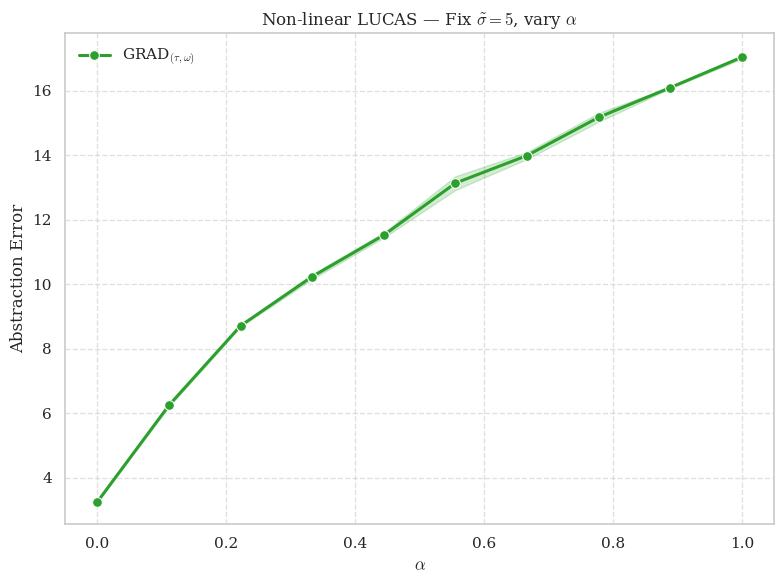

In [10]:
SIGMA_FIXED = 5.0  # your saved file has noise_max=5.0

df_alpha = df_raw[np.isclose(df_raw['noise_scale'], SIGMA_FIXED)].copy()
if df_alpha.empty:
    print("No rows at noise_scale =", SIGMA_FIXED)
else:
    plt.figure(figsize=(8,6))
    sns.lineplot(
        data=df_alpha,
        x='alpha', y='error',
        hue='display',
        hue_order=[pretty_names[m] for m in order_display if m in df_raw['method'].unique()],
        palette=palette,
        marker='o', linewidth=2.2, markersize=7,
        errorbar='sd'
    )
    plt.title(r"Non-linear LUCAS — Fix $\tilde{\sigma}=5$, vary $\alpha$")
    plt.xlabel(r'$\alpha$'); plt.ylabel('Abstraction Error')
    plt.grid(True, ls='--', alpha=0.6)
    plt.legend(title='', frameon=False, loc='best')
    plt.tight_layout()
    plt.show()


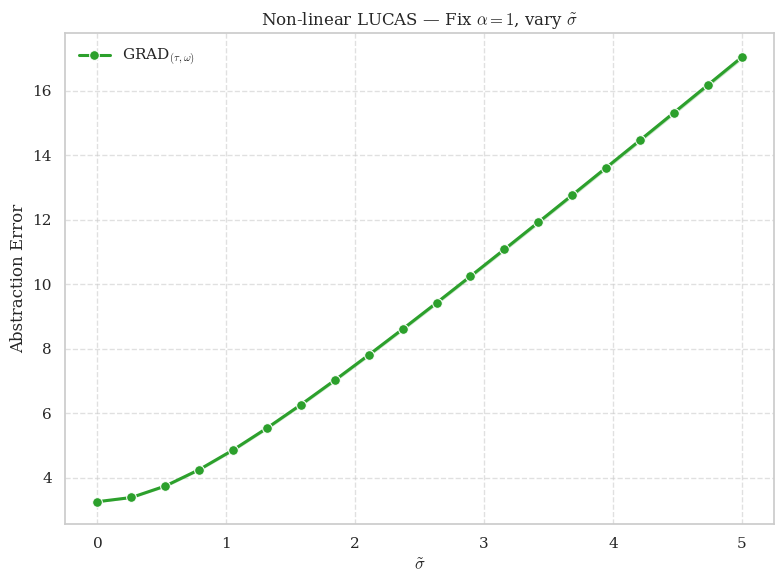

In [11]:
ALPHA_FIXED = 1.0

df_sigma = df_raw[np.isclose(df_raw['alpha'], ALPHA_FIXED)].copy()
if df_sigma.empty:
    print("No rows at alpha =", ALPHA_FIXED)
else:
    plt.figure(figsize=(8,6))
    sns.lineplot(
        data=df_sigma,
        x='noise_scale', y='error',
        hue='display',
        hue_order=[pretty_names[m] for m in order_display if m in df_raw['method'].unique()],
        palette=palette,
        marker='o', linewidth=2.2, markersize=7,
        errorbar='sd'
    )
    plt.title(r"Non-linear LUCAS — Fix $\alpha=1$, vary $\tilde{\sigma}$")
    plt.xlabel(r'$\tilde{\sigma}$'); plt.ylabel('Abstraction Error')
    plt.grid(True, ls='--', alpha=0.6)
    plt.legend(title='', frameon=False, loc='best')
    plt.tight_layout()
    plt.show()


In [12]:
# α = 0 (clean)
clean = df_raw[np.isclose(df_raw['alpha'], 0.0)].copy()
summ = (clean.groupby('display')['error']
        .agg(['mean','std','count'])
        .rename(columns={'mean':'mean_err','std':'std_err'}))
summ['sem'] = summ['std_err']  # trials small; keep std
print("--- α=0.0 summary ---")
display(summ.sort_values('mean_err'))

# α = 1, σ = 5
point = df_raw[np.isclose(df_raw['alpha'], 1.0) & np.isclose(df_raw['noise_scale'], 5.0)].copy()
summ2 = (point.groupby('display')['error']
         .agg(['mean','std','count'])
         .rename(columns={'mean':'mean_err','std':'std_err'}))
summ2['sem'] = summ2['std_err'] / np.sqrt(np.maximum(1, summ2['count']))
print("--- α=1.0, σ=5.0 summary ---")
display(summ2.sort_values('mean_err'))


--- α=0.0 summary ---


,mean_err,std_err,count,sem
display,,,,
"GRAD$_{(\tau, \omega)}$",3.255906,0.00741,200,0.00741


--- α=1.0, σ=5.0 summary ---


,mean_err,std_err,count,sem
display,,,,
"GRAD$_{(\tau, \omega)}$",17.036181,0.048789,10,0.015428


In [13]:
# α = 0 summary
clean = df_raw[np.isclose(df_raw['alpha'], 0.0)]
summ = clean.groupby('display')['error'].agg(['mean','std','count'])
print("α=0 summary:")
display(summ)

# α = 1, σ = 5 (if exists)
point = df_raw[np.isclose(df_raw['alpha'], 1.0) & np.isclose(df_raw['noise_scale'], 5.0)]
if len(point):
    print("α=1, σ=5 summary:")
    display(point.groupby('display')['error'].agg(['mean','std','count']))
else:
    print("No rows at α=1, σ=5 yet.")


α=0 summary:


,mean,std,count
display,,,
"GRAD$_{(\tau, \omega)}$",3.255906,0.00741,200


α=1, σ=5 summary:


,mean,std,count
display,,,
"GRAD$_{(\tau, \omega)}$",17.036181,0.048789,10


In [14]:
import os, joblib, pprint, numpy as np

def inspect_nonlinear_results(experiment='lucas'):
    base = f"data/{experiment}/results_nonlinear"
    print(f"[scan] {base}")
    if not os.path.isdir(base):
        print("  ✗ directory not found"); return

    files = sorted(os.listdir(base))
    for f in files:
        if not f.endswith(".pkl"): 
            continue
        path = os.path.join(base, f)
        try:
            obj = joblib.load(path)
        except Exception as e:
            print(f"  ✗ {f}: failed to load -> {e}")
            continue

        print(f"  • {f}")
        if isinstance(obj, dict):
            # expected layout: { 'fold_0': {...}, 'fold_1': {...}, ...}
            fold_keys = [k for k in obj.keys() if k.startswith("fold_")]
            print(f"    folds: {fold_keys or '—'}")
            # try to list “run_id” / method keys per fold
            for fk in fold_keys[:1]:  # show first fold only (concise)
                inner = obj[fk]
                print(f"    {fk} runs: {list(inner.keys())}")
                # show one run’s shape for sanity
                rk = next(iter(inner.keys()), None)
                if rk:
                    run = inner[rk]
                    # run should be {'T_matrix': tensor/ndarray, 'test_indices': ..., ...}
                    T = run.get('T_matrix', None)
                    if T is not None:
                        try:
                            shape = tuple(T.shape) if hasattr(T, 'shape') else None
                        except:
                            shape = None
                        print(f"      T_matrix shape: {shape}")
        else:
            print("    (unexpected object type)", type(obj))

inspect_nonlinear_results('lucas')


[scan] data/lucas/results_nonlinear
  • abslingam_cv_results_empirical.pkl
    folds: ['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4']
    fold_0 runs: ['Perfect', 'Noisy']
      T_matrix shape: (3, 6)
  • baryca_cv_results_empirical.pkl
    folds: ['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4']
    fold_0 runs: ['baryca_run']
      T_matrix shape: (3, 6)
  • diroca_cv_results_empirical.pkl
    folds: ['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4']
    fold_0 runs: ['eps_41.333_delta_41.315', 'eps_1.0_delta_1.0', 'eps_2.0_delta_2.0', 'eps_4.0_delta_4.0']
      T_matrix shape: (3, 6)
  • gradca_cv_results_empirical.pkl
    folds: ['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4']
    fold_0 runs: ['gradca_run']
      T_matrix shape: (3, 6)


In [1]:
import os, glob
import pandas as pd

eval_dir = "data/lucas/evaluation_results"
# pick up the exact file you just wrote (or latest by mtime)
csvs = sorted(glob.glob(f"{eval_dir}/nonlinear_empirical_eval_gaussian_additive_*.csv"), key=os.path.getmtime)
assert csvs, "No evaluation CSVs found!"
csv_path = csvs[-1]
print("Loaded:", os.path.basename(csv_path))

df = pd.read_csv(csv_path)
print("\nCounts by method:")
print(df.groupby("method").size().sort_values(ascending=False))

print("\nalpha uniq:", df["alpha"].nunique(), "noise uniq:", df["noise_scale"].nunique())
df.head()


Loaded: nonlinear_empirical_eval_gaussian_additive_a10_0.00-1.00_s20_0.00-5.00_tr2_20251103_173001.csv

Counts by method:
method
Abs-LiNGAM (Noisy)                  2000
Abs-LiNGAM (Perfect)                2000
BaryCA                              2000
DiRoCA (eps_1.0_delta_1.0)          2000
DiRoCA (eps_2.0_delta_2.0)          2000
DiRoCA (eps_4.0_delta_4.0)          2000
DiRoCA (eps_41.333_delta_41.315)    2000
GradCA                              2000
dtype: int64

alpha uniq: 10 noise uniq: 20


,method,run,alpha,noise_scale,trial,fold,error
0,DiRoCA (eps_41.333_delta_41.315),eps_41.333_delta_41.315,0.0,0.0,0,fold_0,3.251217
1,DiRoCA (eps_41.333_delta_41.315),eps_41.333_delta_41.315,0.0,0.0,0,fold_1,3.244280
2,DiRoCA (eps_41.333_delta_41.315),eps_41.333_delta_41.315,0.0,0.0,0,fold_2,3.260050
3,DiRoCA (eps_41.333_delta_41.315),eps_41.333_delta_41.315,0.0,0.0,0,fold_3,3.257439
4,DiRoCA (eps_41.333_delta_41.315),eps_41.333_delta_41.315,0.0,0.0,0,fold_4,3.265661


In [2]:
label_map_empirical = {
    'DIROCA (eps_41.333_delta_41.315)': 'DiRoCA_star',  # your star radius run
    'DIROCA (eps_1.0_delta_1.0)': 'DIROCA_1',
    'DIROCA (eps_2.0_delta_2.0)': 'DIROCA_2',
    'DIROCA (eps_4.0_delta_4.0)': 'DIROCA_4',
    'GradCA': 'GradCA',
    'BARYCA': 'BARYCA',
    'Abs-LiNGAM (Perfect)': 'Abslin_p',
    'Abs-LiNGAM (Noisy)': 'Abslin_n'
}
print_label_map  = {
    'DiRoCA_star':  r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$',
    'DIROCA_1':     r'DiRoCA$_{1,1}$',
    'DIROCA_2':     r'DiRoCA$_{2,2}$',
    'DIROCA_4':     r'DiRoCA$_{4,4}$',
    'GradCA':       r'GRAD$_{(\tau, \omega)}$',
    'BARYCA':       r'BARY$_{(\tau, \omega)}$',
    'Abslin_p':     r'AbsLin$_{\text{p}}$',
    'Abslin_n':     r'AbsLin$_{\text{n}}$'
}
methods_to_plot = list(print_label_map.keys())

df_plot = df.copy()
df_plot["display"] = df_plot["method"].replace(label_map_empirical).map(print_label_map)
present = sorted(df_plot["display"].dropna().unique())
print("Methods present:", present)


Methods present: ['AbsLin$_{\\text{n}}$', 'AbsLin$_{\\text{p}}$', 'GRAD$_{(\\tau, \\omega)}$']


In [3]:
import re
import numpy as np

# canonical short keys -> pretty labels
print_label_map  = {
    'DiRoCA_star':  r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$',
    'DIROCA_1':     r'DiRoCA$_{1,1}$',
    'DIROCA_2':     r'DiRoCA$_{2,2}$',
    'DIROCA_4':     r'DiRoCA$_{4,4}$',
    'GradCA':       r'GRAD$_{(\tau, \omega)}$',
    'BARYCA':       r'BARY$_{(\tau, \omega)}$',
    'Abslin_p':     r'AbsLin$_{\text{p}}$',
    'Abslin_n':     r'AbsLin$_{\text{n}}$'
}
methods_to_plot = list(print_label_map.keys())

def method_to_key(m: str) -> str:
    s = (m or "").strip()
    low = s.lower()
    # DiRoCA with eps/delta parsing
    if low.startswith("diroca"):
        g = re.search(r"eps_([\d\.]+)_delta_([\d\.]+)", low)
        if g:
            e = float(g.group(1)); d = float(g.group(2))
            # treat equal radii specially
            if abs(e - d) < 1e-9:
                if abs(e - 1.0) < 1e-9: return "DIROCA_1"
                if abs(e - 2.0) < 1e-9: return "DIROCA_2"
                if abs(e - 4.0) < 1e-9: return "DIROCA_4"
                # any other equal pair → star run (data-driven radii)
                return "DiRoCA_star"
            else:
                # unequal radii → group under star as well
                return "DiRoCA_star"
        return "DiRoCA_star"
    if "gradca" in low: return "GradCA"
    if "baryca" in low: return "BARYCA"          # handles 'BaryCA' vs 'BARYCA'
    if "abs-lingam" in low and "perfect" in low: return "Abslin_p"
    if "abs-lingam" in low and "noisy"   in low: return "Abslin_n"
    # fallback: keep original (won't get pretty label)
    return s

# Build columns: canonical key + pretty display
df_plot = df.copy()
df_plot["method_key"] = df_plot["method"].map(method_to_key)
df_plot["display"] = df_plot["method_key"].map(print_label_map)

present = sorted(df_plot["display"].dropna().unique())
print("Methods present (pretty):", present)
print("Keys present:", sorted(df_plot["method_key"].unique()))


Methods present (pretty): ['AbsLin$_{\\text{n}}$', 'AbsLin$_{\\text{p}}$', 'BARY$_{(\\tau, \\omega)}$', 'DiRoCA$_{1,1}$', 'DiRoCA$_{2,2}$', 'DiRoCA$_{4,4}$', 'DiRoCA$_{\\epsilon_\\ell^*, \\epsilon_h^*}$', 'GRAD$_{(\\tau, \\omega)}$']
Keys present: ['Abslin_n', 'Abslin_p', 'BARYCA', 'DIROCA_1', 'DIROCA_2', 'DIROCA_4', 'DiRoCA_star', 'GradCA']


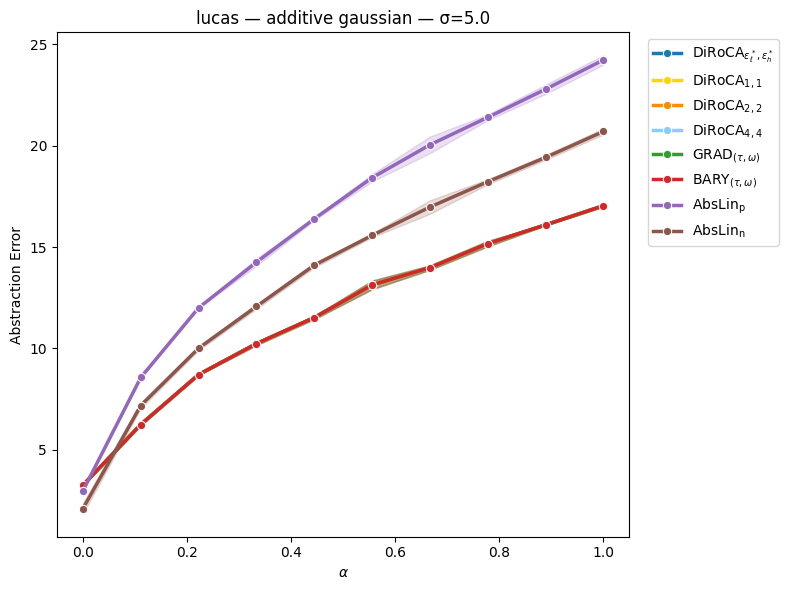

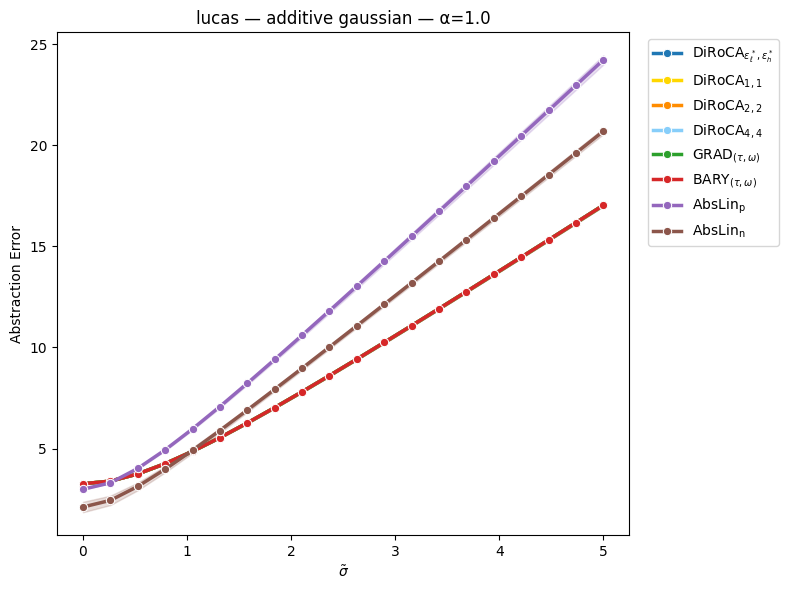

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = {
    r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$': '#1f77b4',
    r'DiRoCA$_{1,1}$': 'gold',
    r'DiRoCA$_{2,2}$': 'darkorange',
    r'DiRoCA$_{4,4}$': 'lightskyblue',
    r'GRAD$_{(\tau, \omega)}$': '#2ca02c',
    r'BARY$_{(\tau, \omega)}$': '#d62728',
    r'AbsLin$_{\text{p}}$': '#9467bd',
    r'AbsLin$_{\text{n}}$': '#8c564b',
}

# fix σ, vary α
noise_fixed = 5.0
sub = df_plot[(df_plot["noise_scale"] == noise_fixed) &
              (df_plot["method_key"].isin(methods_to_plot))].copy()

plt.figure(figsize=(8,6))
sns.lineplot(
    data=sub, x="alpha", y="error",
    hue="display",
    hue_order=[print_label_map[m] for m in methods_to_plot if print_label_map[m] in present],
    palette=palette, marker="o", linewidth=2.5, errorbar="sd"
)
plt.xlabel(r"$\alpha$")
plt.ylabel("Abstraction Error")
plt.title(f"lucas — additive gaussian — σ={noise_fixed}")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# fix α, vary σ
alpha_fixed = 1.0
sub = df_plot[(df_plot["alpha"].sub(alpha_fixed).abs() < 1e-9) &
              (df_plot["method_key"].isin(methods_to_plot))].copy()

plt.figure(figsize=(8,6))
sns.lineplot(
    data=sub, x="noise_scale", y="error",
    hue="display",
    hue_order=[print_label_map[m] for m in methods_to_plot if print_label_map[m] in present],
    palette=palette, marker="o", linewidth=2.5, errorbar="sd"
)
plt.xlabel(r"$\tilde{\sigma}$")
plt.ylabel("Abstraction Error")
plt.title(f"lucas — additive gaussian — α={alpha_fixed}")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
